In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import random

import gymnasium as gym

# Используем среду `Taxi-v3` из https://gymnasium.farama.org/environments/toy_text/taxi/

In [2]:
env = gym.make("Taxi-v3", render_mode="rgb_array")

## в игре возможны разные начальные состояния - фиксируем любое
**NB!:** Очевидно, что оптимальная стретегия зависит не только от среды, но и от начальных позиций такси, клиента и пункта назначения - на момент размещения заказа, скажем, в приложении Яндекс Такси.  Поэтому при обучении придется проигрывать эпизоды из одного и того же состояния - и его надо зафиксировать.  Есть риск (если параметры игры симулируют и такую реальность), что таксисту будет невыгодно принять заказ - тогда политика будет нестабильна (подойдет любая езда мимо клиента!).  Если так случится, поменяем параметр случайности и повторим, а пока возьмем какое-нибудь приятное число:

In [3]:
my_seed = 13

## визуализируем выбранное начальное состояние

<frozen importlib._bootstrap>:488: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
/home/GD/sevastyanov.a/anaconda3/envs/py313_Gymnasium/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


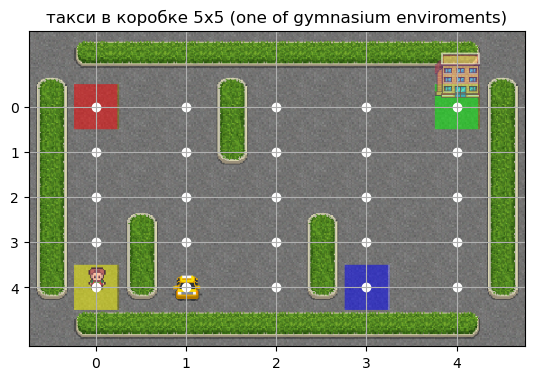

In [4]:
env.reset(seed=my_seed)
plt.imshow(env.render())

mesh = np.array([(74+100*i,84+50*j) for i in range(5) for j in range(5)])
plt.scatter(mesh[:,0], mesh[:,1], color='white')
plt.xticks([74+100*i for i in range(5)], labels=[str(i) for i in range(5)])
plt.yticks([84+50*i for i in range(5)], labels=[str(i) for i in range(5)])
plt.title('такси в коробке 5х5 (one of gymnasium enviroments)')
plt.grid()
plt.show()

### пояснения к картинке:
0) объекты игры: такси, клиент, пункт назначения, 4 места посадки/высадки,  сетка локаций (5х5) остальных объектов с ограничением: локации клиента и пункта назначения ограничены локациями мест посадки/высадки, а у клиента есть особый статус "в такси" (без локации или локацию можно считать совпадающей с локацией такси)
1) где такси и клиент - очевидно, а вот домик, скорее всего, визуализирует пункт назначения
2) белые точки локаций - возможные положения такси в ходе игры
3) цветные квадраты - разрешенные места посадки и высадки клиента
4) зеленые газоны ограничивают возможные действия в соседних точках - их нельзя пересекать со следующей реализацией: при выборе дествия с движением на газон перемещения такси в ответе среды не происходит, но инкрементируется время (которое штрафуется регулярным образом)

## СОСТОЯНИЯ среды (observation space)

### являются ли положения газонов и мест посадки/высадки также состояниями среды - просто экспериментируем с инициализацией без задания постоянного `seed` (ответ *нет*):

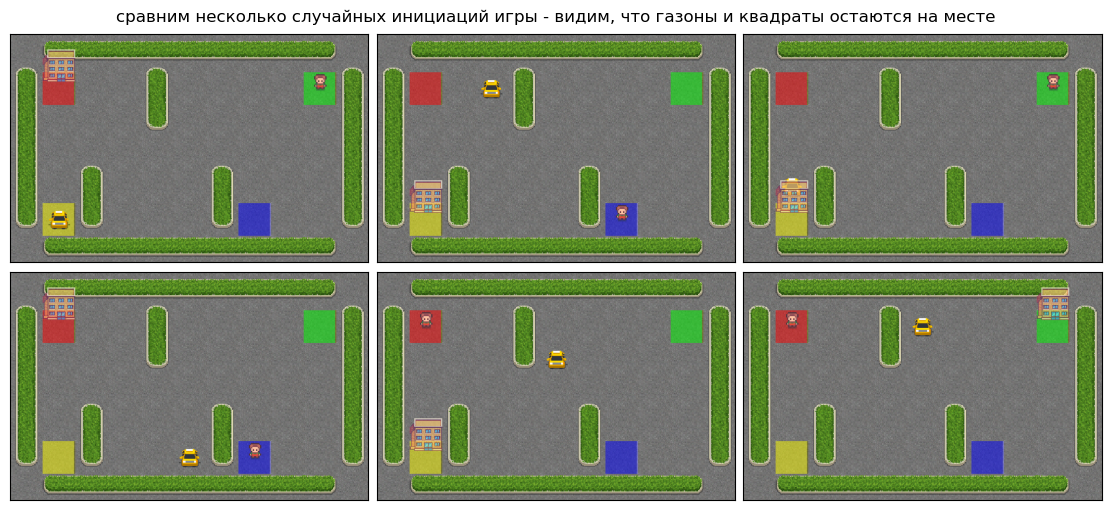

In [5]:
fig, axes = plt.subplots(2,3,figsize=(11,5), layout='constrained')
axes = axes.flatten()

for ax in axes:
    env.reset()
    env.reset()
    ax.imshow(env.render())
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('сравним несколько случайных инициаций игры - видим, что газоны и квадраты остаются на месте')
plt.show()

### сколько в итоге состояний

#### без выбора `seed`
пункт назначения выбирается 4 способами:
* `0` = красный
* `1` = зеленый
* `2` = желтый
* `3` = синий

статус клиента выбирается 5 способами минус 1 (не совпадает с пунктом назначения) - так значится в описании на https://gymnasium.farama.org/environments/toy_text/taxi/, однако заметим, что это противоречит списку вознаграждений, где остался штраф за посадку/высадку вне положенных 4 мест (скорее всего, одно из двух осталось от прежних версий):
* `0` = красный
* `1` = зеленый
* `2` = желтый
* `3` = синий
* `4` = в такси

статус такси задается его положением в сетке 5х5 - то есть 25 вариантов

**итого получаем 4х4х25=400 достижимых состояний без выбора `seed`**

#### после выбора `seed`

пункт назначения фиксирован в одном состоянии

статусы клиента и такси выбираются также

**итого получаем 1х4х25=100 достижимых состояний после выбора `seed`**

In [6]:
print('Сравним с размерностью пространства состояний заданной в самой среде: ', env.observation_space.n)

Сравним с размерностью пространства состояний заданной в самой среде:  500


**размерность пространства состояний в среде задана без учета ограничений, поэтому не все они достижимы**

### кодирование пространства состояний проводится по формуле

$$
observation = 4\cdot \Big( 5\cdot(5\cdot taxi_y+ taxi_x) + passenger \Big) + destination
$$

## ДЕЙСТВИЯ агента/игрока (action space)

**с рядом условных ограничений диапазон действия агента таков:**
* `0` = вниз    (нет движения по газону, попытка по умолчанию штрафуется пропуском временного хода)
* `1` = вверх   (аналогично выше)
* `2` = вправо  (аналогично выше)
* `3` = влево   (аналогично выше)
* `4` = посадка (только если на клетке такси есть клиент, при том, что в начальном состоянии он только на 4 местах посадки/высадки)
* `5` = высадка (судя по списку вознаграждений, возможно не только на 4 местах посадки/высадки)

In [7]:
print('Сравним с размерностью пространства действий заданной в самой среде: ', env.action_space.n)

Сравним с размерностью пространства действий заданной в самой среде:  6


## ЭПИЗОД

### начало
стартуем все эпизоды обучения в состоянии, фиксируемом параметром `seed` вызова функции `env.reset()` - поскольку для каждого исходного состояния оптимальная стратегия своя

### конец
#### завершение (termination)
применено действие высадка клиента (тоже некоторое противоречие вознаграждениям)
#### прерывание (truncation)
длина эпизода превысила лимит шагов (200)

## ВОЗНАГРАЖДЕНИЯ
* ` -1` добавляется в интегральному счету на каждом шаге по времени
* `+20` высадка клиента в пункте назначения (при этом эпизод заканчивается)
* `-10` посадка/высадка клиента вне 4 положенных мест - видимо, в последней версии превратилось в "высадка клиента вне пункта назначения" 

## $Q(s,a)$ будет дискретной $Q[s,a]$-матрицей

In [8]:
print('Q[s,a]-матрица будет иметь размеры:', env.observation_space.n, 'x', env.action_space.n)

Q[s,a]-матрица будет иметь размеры: 500 x 6


**хотя не все эти состояния будут посещаемы алгоритмом!**

# Поиск оптимальной стратегии методом Monte-Carlo (попытка №1)

## $P(s)$ будет `epsilon-greedy`
кстати, вот тут мы должны были бы в варианте $\epsilon$ применить ограничения, но для простоту просто сэмплируем любое действие - ожидая, что среда сама отработает ограничения

In [9]:
def policy_f(Q, s, eps=0.1):
    if random.random() < eps:
        return env.action_space.sample() 
    else:
        return np.argmax(Q[s])

## Алгоритм Монте-Карло

### цикл по эпизодам оформим как обучающую функцию, возвращающую обученную Q-матрицу 

In [10]:
def training_f(Q='none', keep_seed=True, debug_run=False, play_optimal_policy=False, gamma=0.99):
    if type(Q) is str:
        Q = np.zeros((env.observation_space.n, env.action_space.n))
    
    # initiate arrays used by MC-algorythm below
    observed_sum = np.zeros_like(Q)
    observations_count = np.zeros_like(Q)
    # and logs for posterior visualization
    reward_history = []
    length_history = []

    if debug_run or play_optimal_policy:
        num_episodes = 1
    else:
        num_episodes = 10000                  # training iterations of full played episode
        
    for episode in range(num_episodes):
        # restart episode
        done = False
        total_reward = 0
        episode_trace = []
        
        if keep_seed:
            state, info = env.reset(seed=my_seed)
        else:
            state, info = env.reset()
            
        # see in debug what happens now
        if debug_run: 
            print('debug restarting episode from state:', state, info)
        else:
            if (episode+1) % 100 == 0:
                print('playing episode', episode+1, 'of total', num_episodes, end=', please wait! \r')

        # playing one episode till the end
        episode_len = 0
        while not done:
            episode_len += 1
            if play_optimal_policy: 
                action = policy_f(Q, state, 0.0)                       # тут мутации не нужны
            elif debug_run:
                action = policy_f(Q, state, 0.1)
            else:
                action = policy_f(Q, state, 1/np.sqrt(1+episode))      # увеличиваем мутации на первых эпизодах и медленно уменьшаем
            
            next_state, reward, terminated, truncated, info = env.step(action)
            episode_trace.append((state, action, reward, info['action_mask']))
                
            state = next_state
            total_reward += reward
            if terminated or truncated:
                done = True

        reward_history.append(total_reward)
        length_history.append(episode_len)
        
        # see in debug what happens now
        if debug_run: 
            print('-'*50)
            print('debug ending episode: episode_trace:')
            for s,a,r,a_mask in episode_trace:
                print ('  state =', s, '  action =', a, '  reward =', r, '   action_mask =', a_mask)
            print('-'*50)
            print("episode's total reward =", total_reward)
    
        # and here is in fact the implementation of MC-algorythm for updating Q-matrix:
        G = 0
        handled_state_action_pairs = set()
        for t in reversed(range(len(episode_trace))):
            s, a, r, a_mask = episode_trace[t]
            G = gamma * G + r

            # check if this is first occurrence of the (s,a)-pair in the episode
            if (s, a) not in handled_state_action_pairs:
                # as per MC-algorythm
                observed_sum[s][a] += G
                observations_count[s][a] += 1
                Q[s][a] = observed_sum[s][a] / observations_count[s][a]
                # save first occurance of the (s,a)-pair
                handled_state_action_pairs.add((s, a))
    
        # see in debug what happens now
        if debug_run: 
            print('-'*50)
            print('debug (s,a)-pairs engaged in the episode:')
            for s,a in handled_state_action_pairs:
                print ('  state =', s, '  action =', a)

    return np.copy(Q), reward_history, length_history

### посмотрим все ли и как оно работает на одном шаге с нулевой инициацией Q-матрицы

In [11]:
print('\nПосле первого шага Q[s,a] обновлена в', (training_f(debug_run=True)[0].flatten() != 0.0).sum(), 'ячейках/клетках')

debug restarting episode from state: 429 {'prob': 1.0, 'action_mask': array([0, 1, 1, 0, 0, 0], dtype=int8)}
--------------------------------------------------
debug ending episode: episode_trace:
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 4

**ВЫВОДЫ из дебаг-прогона одного эпизода:**
1) как мы видим, такси долго толчется на месте - причина в неудачном стечении трех обстоятельств:
   * при выбранном `seed` такси стартует в углу газонов
   * начальная Q-матрица заполнена нулями, поэтому `argmax` в функции полиси ничего не выбирает, а хватает первое значение (0) из списка действий
   * действие 0 - это движение вниз, на газон при нашем `seed` 
2) поэтому такси выбирается из угла только за счет эпсилон-мутации при выборе политики
3) в результате понадобится много попыток, чтобы оторвать Q-матрицу от ее начальных нулей

### что делать?
1) можно инициировать Q-матрицу случайными значениями, ограниченными по модулю << 1, но которые дадут работать `argmax` сразу
2) можно завысить эпсилон на первых эпизодах - что мы и сделали в коде выше: $\epsilon=\frac{1}{\sqrt{1+i_{эпизода}}}$ - и на 10000 итераций эпсилон все еще неплох: на уровне 1%

# Прогон №1 алгоритма обучения на 10000 эпизодах

In [12]:
Q_fitted, rewards_story, len_story = training_f()

playing episode 10000 of total 10000, please wait! 

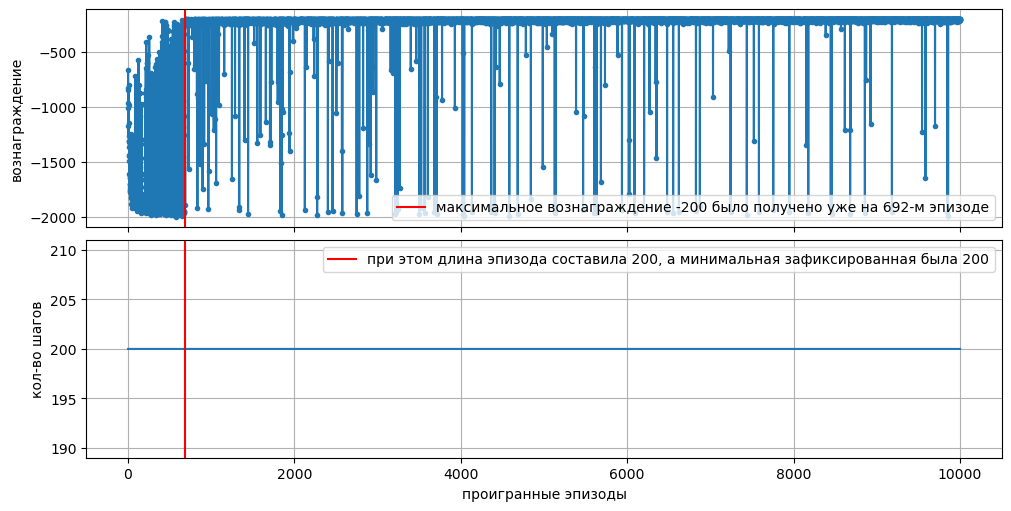

In [13]:
first_best_idx = np.argmax(rewards_story)

fig, (ax1,ax2) = plt.subplots(2,1,figsize=(10,5), layout='constrained', sharex=True)

ax1.plot(range(1,len(rewards_story)+1), rewards_story, marker='.')
ax1.axvline(first_best_idx, color='red', label='максимальное вознаграждение ' + str(rewards_story[first_best_idx]) + 
                                               ' было получено уже на ' + str(first_best_idx+1) + '-м эпизоде')
ax1.set_ylabel('вознаграждение')
ax1.grid()
ax1.legend(loc='lower right')                                        

ax2.plot(range(1,len(len_story)+1), len_story)
ax2.axvline(first_best_idx, color='red', label='при этом длина эпизода составила ' + str(len_story[first_best_idx]) + 
                                               ', а минимальная зафиксированная была ' + str(np.min(len_story)))
ax2.set_ylabel('кол-во шагов')
ax2.set_xlabel('проигранные эпизоды')
ax2.grid()
ax2.legend(loc='upper right')

plt.show()

## смотрим один эпизод действий по обучившейся политике

In [14]:
print('\nПосле обучения Q[s,a] обновлена в', (training_f(Q=Q_fitted, debug_run=True, play_optimal_policy=True)[0].flatten() != 0.0).sum(), 
      'ячейках/клетках')

debug restarting episode from state: 429 {'prob': 1.0, 'action_mask': array([0, 1, 1, 0, 0, 0], dtype=int8)}
--------------------------------------------------
debug ending episode: episode_trace:
  state = 429   action = 1   reward = -1    action_mask = [1 1 1 0 0 0]
  state = 329   action = 1   reward = -1    action_mask = [1 1 1 1 0 0]
  state = 229   action = 2   reward = -1    action_mask = [1 1 1 1 0 0]
  state = 249   action = 1   reward = -1    action_mask = [1 1 1 0 0 0]
  state = 149   action = 2   reward = -1    action_mask = [1 1 1 1 0 0]
  state = 169   action = 2   reward = -1    action_mask = [1 1 0 1 0 0]
  state = 189   action = 1   reward = -1    action_mask = [1 0 0 1 0 0]
  state = 89   action = 1   reward = -1    action_mask = [1 0 0 1 0 0]
  state = 89   action = 1   reward = -1    action_mask = [1 0 0 1 0 0]
  state = 89   action = 1   reward = -1    action_mask = [1 0 0 1 0 0]
  state = 89   action = 1   reward = -1    action_mask = [1 0 0 1 0 0]
  state = 89   

## у нас получился не таксист, а сачёк!
Как сказано в книге "Физики шутят", настоящий теорфизик за пять минут может объяснить результаты любого эксперимента как совершенно очевидные и ожидаемые - даже если держит график измерений вверх ногами!

Вот и мы не удивлены результатами - поскольку шансов допрыгнуть с пассажиром на борту до места назначения, да еще и догадаться его там высадить крайне мало, то алгоритм сваливается в локальный максимум - минимизируя штрафы за неверные места посадки/высадки, которые генерятся эпсилон-стохастичностью в функции политики.  Таксист быстро обучается просто не брать пассажира, при этом окончательно обнуляя свои шансы увидеть приз, так как даже добравшись до зоны высадки он не имеет пассажира на борту!

# Прогон №2 алгоритма обучения на 10000 эпизодах - без `seed`

## возможно, мы слишком заперли таксиста в углу нашим `seed` - уберем стартование всех эпизодов при одних начальных условиях

In [15]:
Q_fitted, rewards_story, len_story = training_f(keep_seed=False)

playing episode 10000 of total 10000, please wait! 

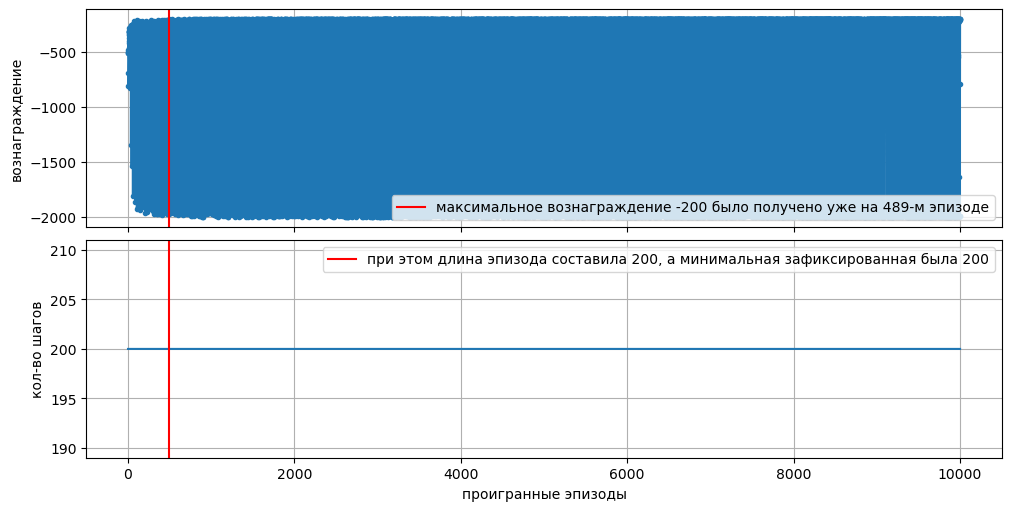

In [16]:
first_best_idx = np.argmax(rewards_story)

fig, (ax1,ax2) = plt.subplots(2,1,figsize=(10,5), layout='constrained', sharex=True)

ax1.plot(range(1,len(rewards_story)+1), rewards_story, marker='.')
ax1.axvline(first_best_idx, color='red', label='максимальное вознаграждение ' + str(rewards_story[first_best_idx]) + 
                                               ' было получено уже на ' + str(first_best_idx+1) + '-м эпизоде')
ax1.set_ylabel('вознаграждение')
ax1.grid()
ax1.legend(loc='lower right')                                        

ax2.plot(range(1,len(len_story)+1), len_story)
ax2.axvline(first_best_idx, color='red', label='при этом длина эпизода составила ' + str(len_story[first_best_idx]) + 
                                               ', а минимальная зафиксированная была ' + str(np.min(len_story)))
ax2.set_ylabel('кол-во шагов')
ax2.set_xlabel('проигранные эпизоды')
ax2.grid()
ax2.legend(loc='upper right')

plt.show()

## смотрим один эпизод действий по обучившейся политике

In [17]:
print('\nПосле обучения Q[s,a] обновлена в', (training_f(Q=Q_fitted, debug_run=True, play_optimal_policy=True)[0].flatten() != 0.0).sum(), 
      'ячейках/клетках')

debug restarting episode from state: 429 {'prob': 1.0, 'action_mask': array([0, 1, 1, 0, 0, 0], dtype=int8)}
--------------------------------------------------
debug ending episode: episode_trace:
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 429   action = 0   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 4

## теперь получился не сачёк, а халявщик
Видно, что даже если в некоторых случаях у таксиста получалось достигнуть цели, но на 10 000 эпизодах при 12х23 = 276 разных начальных условий, размороженных убранным `seed`, обучение не успевает сойтись (попробовал и на 100 000 эпизодах - тоже не успевает, а дальнейшее увеличение требует повышения быстродействия!)

# Костыли некошерности
Смирим гордыню - не будем ждать всех милостей из Монте-Карло, часть возьмем сами детерминированной логикой:  как легко заметить, даже после обучения агент совершает много бессмысленных действий, вроде езды в стену.  Попробуем ограничить его от таковых.  Кстати в параметре info метод `env.step(action)` возвращает нам `action_mask`, которая, видимо, служит как раз этой цели - воспользуемся!

Кроме того, эмпирически обнаружено, что даже с маской действий иногда обучение сваливается в замкнутый круг шагов туда-сюда, поэтому будет разумно сперва стартовать на меньшем числе ходов, а потом продолжить только самый удачный старт 

In [18]:
max_runs = 3000       # обычно уже к четвертой тысяче все ясно!

## полиси перепишем так, чтобы она могла выбирать ответы только из разрешенных маской действий (поскольку маска - есть функция состояния, то при этом полиси останется $P(s)$ )

In [19]:
def policy_f(Q, s, mask=[1,1,1,1,1,1], eps=0.1):
    if random.random() < eps:
        return random.choice(np.where(mask)[0]) 
    else:
        return np.where(mask)[0][ np.argmax( Q[s][ np.where(mask)[0] ] ) ]

## теперь при вызове надо передавать маску - поэтому перепишется и функция обучения `training_f`

In [20]:
def training_f(Q='none', keep_seed=True, debug_run=False, play_optimal_policy=False, gamma=0.7):
    if type(Q) is str:
        Q = np.zeros((env.observation_space.n, env.action_space.n))
    
    # initiate arrays used by MC-algorythm below
    observed_sum = np.zeros_like(Q)
    observations_count = np.zeros_like(Q)
    # and logs for posterior visualization
    reward_history = []
    length_history = []

    if debug_run or play_optimal_policy:
        num_episodes = 1
    else:
        num_episodes = max_runs                  # training iterations of full played episode
        
    for episode in range(num_episodes):
        # restart episode
        done = False
        total_reward = 0
        episode_trace = []
        
        if keep_seed:
            state, info = env.reset(seed=my_seed)
        else:
            state, info = env.reset()
        mask = info['action_mask']
            
        # see in debug what happens now
        if debug_run: 
            print('debug restarting episode from state:', state, info)
        else:
            if (episode+1) % 100 == 0:
                print('playing episode', episode+1, 'of total', num_episodes, 'for gamma =', gamma, end=', please wait! \r')

        # playing one episode till the end
        episode_len = 0
        while not done:
            episode_len += 1
                        
            if play_optimal_policy: 
                action = policy_f(Q, state, mask, 0.0)                    # тут мутации не нужны и маски нет
            elif debug_run:
                action = policy_f(Q, state, mask)
            else:
                action = policy_f(Q, state, mask, 1/np.sqrt(1+episode))   # увеличиваем мутации на первых эпизодах и медленно уменьшаем
            
            next_state, reward, terminated, truncated, info = env.step(action)
            next_mask = info['action_mask']
            episode_trace.append((state, action, reward, mask))
                
            state = next_state
            mask = next_mask
            total_reward += reward
            if terminated or truncated:
                done = True

        reward_history.append(total_reward)
        length_history.append(episode_len)
        
        # see in debug what happens now
        if debug_run: 
            print('-'*50)
            print('debug ending episode: episode_trace:')
            for s,a,r,a_mask in episode_trace:
                print ('  state =', s, '  action =', a, '  reward =', r, '   action_mask =', a_mask)
            print('-'*50)
            print("episode's total reward =", total_reward)
    
        # and here is in fact the implementation of MC-algorythm for updating Q-matrix:
        G = 0
        handled_state_action_pairs = set()
        for t in reversed(range(len(episode_trace))):
            s, a, r, a_mask = episode_trace[t]
            G = gamma * G + r

            # check if this is first occurrence of the (s,a)-pair in the episode
            if (s, a) not in handled_state_action_pairs:
                # as per MC-algorythm
                observed_sum[s][a] += G
                observations_count[s][a] += 1
                Q[s][a] = observed_sum[s][a] / observations_count[s][a]
                # save first occurance of the (s,a)-pair
                handled_state_action_pairs.add((s, a))
    
        # see in debug what happens now
        if debug_run: 
            print('-'*50)
            print('debug (s,a)-pairs engaged in the episode:')
            for s,a in handled_state_action_pairs:
                print ('  state =', s, '  action =', a)

    return np.copy(Q), reward_history, length_history

### Прогон №3 алгоритма обучения на 3000 эпизодах - с маской для действий агента и многократным стартом

#### the good start find training

In [21]:
Q_saved = []
rewards_saved = []
len_saved = []

for gamma_i in ([0.5 + 0.05*i for i in range(10)] + [0.97, 0.99]):
    print()
    Q_fitted, rewards_story, len_story = training_f(gamma=gamma_i)
    Q_saved.append(Q_fitted)
    rewards_saved.append(rewards_story)
    len_saved.append(len_story)


playing episode 3000 of total 3000 for gamma = 0.5, please wait! 
playing episode 3000 of total 3000 for gamma = 0.55, please wait! 
playing episode 3000 of total 3000 for gamma = 0.6, please wait! 
playing episode 3000 of total 3000 for gamma = 0.65, please wait! 
playing episode 3000 of total 3000 for gamma = 0.7, please wait! 
playing episode 3000 of total 3000 for gamma = 0.75, please wait! 
playing episode 3000 of total 3000 for gamma = 0.8, please wait! 
playing episode 3000 of total 3000 for gamma = 0.8500000000000001, please wait! 
playing episode 3000 of total 3000 for gamma = 0.9, please wait! 
playing episode 3000 of total 3000 for gamma = 0.95, please wait! 
playing episode 3000 of total 3000 for gamma = 0.97, please wait! 
playing episode 3000 of total 3000 for gamma = 0.99, please wait! 

#### let's see the good start find training results

/tmp/.private/sevastyanov.a/ipykernel_344263/1592044372.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend(loc='lower right', title='last 1/4 avg(r) = '+str(round(np.mean(rewards_saved[i][-750:]))))


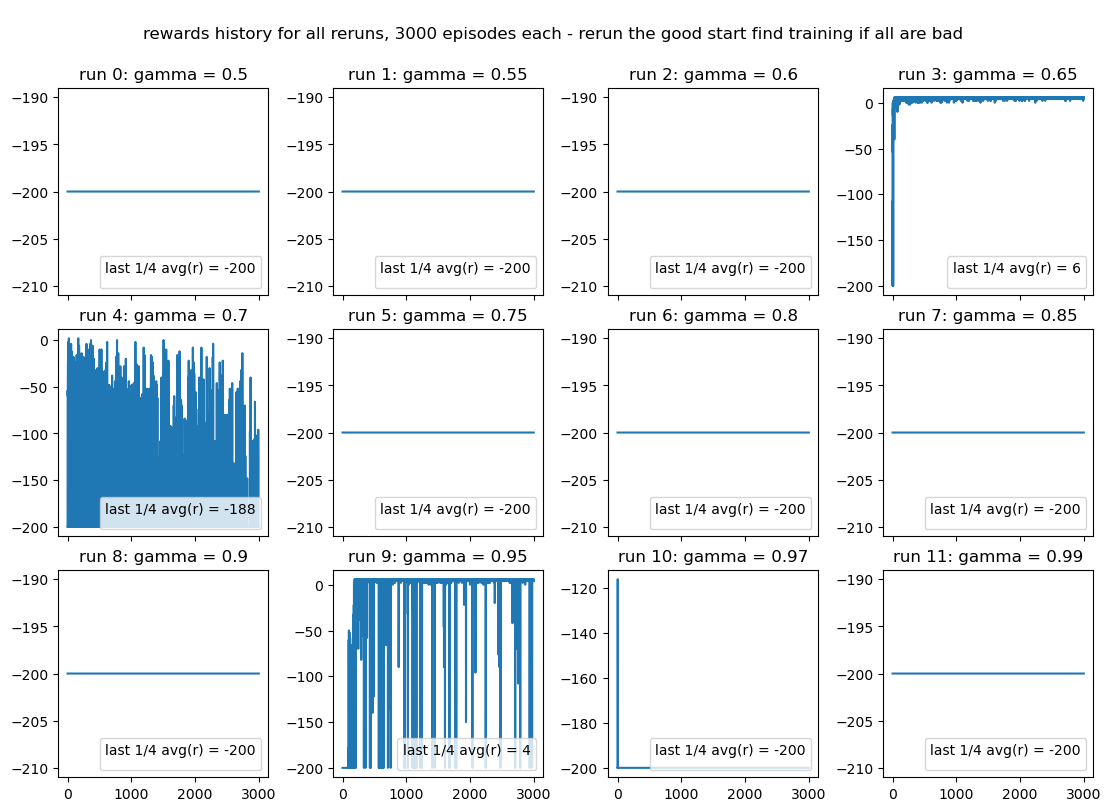

In [22]:
fig, ax = plt.subplots(3,4,figsize=(11,8), layout='constrained', sharex=True)
ax = ax.flatten()

for i in range(len(len_saved)):
    ax[i].plot(rewards_saved[i])
    ax[i].set_title('run '+str(i)+': gamma = '+str(round( ([0.5 + 0.05*i for i in range(10)] + [0.97, 0.99])[i] ,2)) )
    ax[i].legend(loc='lower right', title='last 1/4 avg(r) = '+str(round(np.mean(rewards_saved[i][-750:]))))

fig.suptitle('\nrewards history for all reruns, 3000 episodes each - rerun the good start find training if all are bad \n')
plt.show()

In [23]:
metrics = [np.mean(rewards[-750:]) for rewards in rewards_saved]
if np.max(metrics) < 0.0:
    print ('\nFYI: к сожалению, ни одна попытка обучения на 3000 эпизодах не была удачной - повторите "the good start find training"')
else:
    best_try_idx = np.argmax(metrics)
    Q_best = np.copy(Q_saved[best_try_idx])
    g_best = round( ([0.5 + 0.05*i for i in range(10)] + [0.97, 0.99])[best_try_idx],2)
    print('\nFYI: поздравляем, ваш агент нашел правильный путь - имя оптимальной Q-функции: Q_best при гамма =', g_best)
    print()
    print('\nПосле обучения Q[s,a] обновлена в', 
          (training_f(Q=Q_best, debug_run=True, play_optimal_policy=True, gamma=g_best)[0].flatten() != 0.0).sum(), 
          'ячейках/клетках')


FYI: поздравляем, ваш агент нашел правильный путь - имя оптимальной Q-функции: Q_best при гамма = 0.65

debug restarting episode from state: 429 {'prob': 1.0, 'action_mask': array([0, 1, 1, 0, 0, 0], dtype=int8)}
--------------------------------------------------
debug ending episode: episode_trace:
  state = 429   action = 1   reward = -1    action_mask = [0 1 1 0 0 0]
  state = 329   action = 1   reward = -1    action_mask = [1 1 1 0 0 0]
  state = 229   action = 3   reward = -1    action_mask = [1 1 1 1 0 0]
  state = 209   action = 0   reward = -1    action_mask = [1 1 1 0 0 0]
  state = 309   action = 0   reward = -1    action_mask = [1 1 0 0 0 0]
  state = 409   action = 4   reward = -1    action_mask = [0 1 0 0 1 0]
  state = 417   action = 1   reward = -1    action_mask = [0 1 0 0 0 1]
  state = 317   action = 1   reward = -1    action_mask = [1 1 0 0 0 0]
  state = 217   action = 2   reward = -1    action_mask = [1 1 1 0 0 0]
  state = 237   action = 2   reward = -1    action

**можно продолжить обучение до 10000 эпизодов, стартовав с $Q=Q_{best}$ и $\gamma=\gamma_{best}$, но уже и по текстовому выводу выше видно, что агент отлично обучился!  Заметим, что это не определяется значением гамма - а только случайным стартом алгоритма, видимо, Монте-Карло неустойчив к стартовым данным для среды Такси**

# Матожидание вознаграждения - поскольку в Монте-Карло нет стохастического выбора на уровне стратегии, то вознаграждение при применении $Q_{best}$ будет константным

# Визуализируем один эпизод действий агента по найденной оптимальной стратегии в виде мультфильма в отдельном окне:

In [32]:
from time import sleep
cartoon_env = gym.make('Taxi-v3', render_mode="human")

new_state, new_info = cartoon_env.reset(seed=my_seed)
episode_over = False
while not episode_over:
    new_mask = new_info['action_mask']
    action = policy_f(Q_best, new_state, new_mask, 0.0)
    new_state, reward, terminated, truncated, new_info = cartoon_env.step(action)
    episode_over = terminated or truncated
    sleep(0.5)

## run cell above again and again to enjoi the optimal stategy found!